In [1]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta, timezone
import talib as ta
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# 參數
ticker = "^TWII"   # TAIEX on Yahoo
start = "2019-09-29"
end_inclusive = "2025-10-03"

# yfinance 的 end 是「不含」當天，所以加 1 天
end_exclusive = (datetime.strptime(end_inclusive, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d")

# 下載資料（日線）
df = yf.download(ticker, start=start, end=end_exclusive, interval="1d", auto_adjust=False)

# 整理欄位
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"]).dt.date
df = df[["Date", "Open", "High", "Low", "Close", "Volume"]]

# 輸出成 CSV
out_file = "HW3.csv"
df.to_csv(out_file, index=False, encoding="utf-8-sig")


[*********************100%***********************]  1 of 1 completed


In [3]:
# === 參數設定 ===
UP_PCT = 0.04     # 上界 +4%
DOWN_PCT = 0.02   # 下界 -2%
MAX_HOLD = 20     # 垂直障礙 20 天

# === 讀取資料 ===
df = pd.read_csv("HW3.csv")

# 確保數值欄位為 float
for col in ["Open", "High", "Low", "Close", "Volume"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# === Triple Barrier ===
labels = []
high = df["High"].values
low = df["Low"].values
close = df["Close"].values
n = len(df)

for i in range(n):
    entry = close[i]
    if pd.isna(entry):
        labels.append(None)
        continue

    ub = entry * (1 + UP_PCT)
    lb = entry * (1 - DOWN_PCT)

    label = 0  # 預設垂直障礙
    start = i + 1
    end = min(i + 1 + MAX_HOLD, n)

    for j in range(start, end):
        if high[j] >= ub and low[j] <= lb:
            label = 0  # 同日同時觸發，視為無法判定
            break
        elif high[j] >= ub:
            label = 1  # 上界先觸發
            break
        elif low[j] <= lb:
            label = 2  # 下界先觸發
            break

    labels.append(label)

# === 存回原檔（只新增 TB_Label） ===
df["TB_Label"] = labels
df.to_csv("HW3.csv", index=False, encoding="utf-8-sig")

print(f"完成！已將 TB_Label 加入 HW3.csv，共 {len(df)} 筆。")

完成！已將 TB_Label 加入 HW3.csv，共 1464 筆。


In [4]:
# === Bias ratio： (Close / SMA - 1) * 100 ===
def bias(close, window):
    sma = ta.SMA(close, timeperiod=window)
    return (close / sma - 1.0) * 100.0

df["BIAS_5"]  = bias(close, 5)
df["BIAS_10"] = bias(close, 10)
df["BIAS_20"] = bias(close, 20)
df["BIAS_60"] = bias(close, 60)

# === RSI(14) ===
df["RSI_14"] = ta.RSI(close, timeperiod=14)

# === MACD(12,26,9) ===
macd, macd_signal, macd_hist = ta.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
df["MACD_DIF"]    = macd          # 快線 DIF
df["MACD_SIGNAL"] = macd_signal   # 慢線 Signal
df["MACD_HIST"]   = macd_hist     # 柱狀

# === 輸出：覆寫同一份 CSV（包含問題1+2+3） ===
df = df.sort_values("Date").reset_index(drop=True)
df.to_csv("HW3.csv", index=False, encoding="utf-8-sig")


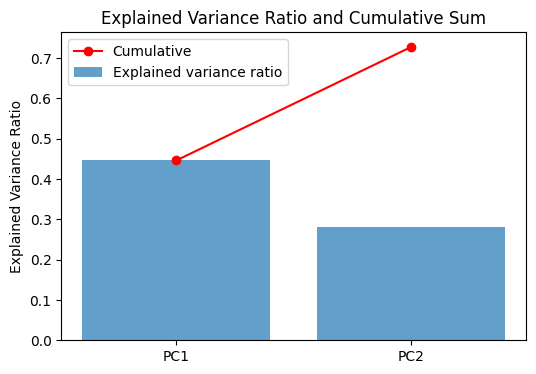

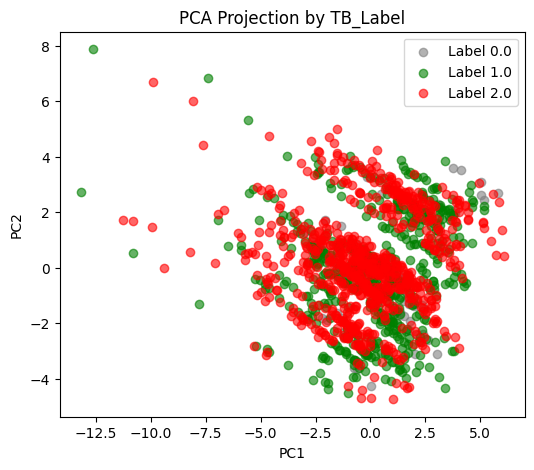

In [5]:
# === 讀取資料 ===
df = pd.read_csv("HW3.csv")

# 選取 Problem 1 + Problem 3 的特徵
features = ["Open", "High", "Low", "Close", "Volume",
            "BIAS_5", "BIAS_10", "BIAS_20", "BIAS_60",
            "RSI_14", "MACD_DIF", "MACD_SIGNAL", "MACD_HIST"]

X = df[features].dropna()
y = df.loc[X.index, "TB_Label"]

# === 標準化 ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === PCA 降維至2維 ===
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 取解釋變異比例
explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

# === (A) 繪出解釋變異比例 ===
plt.figure(figsize=(6,4))
plt.bar(range(1, 3), explained, alpha=0.7, label="Explained variance ratio")
plt.plot(range(1, 3), cum_explained, marker="o", color="red", label="Cumulative")
plt.xticks([1, 2], ["PC1", "PC2"])
plt.ylabel("Explained Variance Ratio")
plt.legend()
plt.title("Explained Variance Ratio and Cumulative Sum")
plt.show()

# === (B) 繪出 PCA 平面分類圖 ===
plt.figure(figsize=(6,5))
colors = {0: "gray", 1: "green", 2: "red"}
for label in sorted(y.unique()):
    plt.scatter(X_pca[y==label, 0], X_pca[y==label, 1],
                label=f"Label {label}", alpha=0.6, c=colors[label])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA Projection by TB_Label")
plt.show()
